# Aula: Redes Neurais (MLP e RNN) — Classificação e Regressão

**Resumo das etapas:**
1. Preparar ambiente (instalar dependências no Colab, se preciso)
2. Importar bibliotecas
3. Carregar dados de exemplo (classificação e regressão)
4. Exploração rápida dos dados (EDA)
5. Pré-processamento e limpeza
6. Treinar MLP (classificação e regressão) com scikit-learn
7. Converter dados tabulares para sequências didáticas e treinar RNN (LSTM) com Keras
8. Avaliação e visualizações com comentários detalhados
9. Tarefas propostas para os alunos

> Observação: células de instalação podem ser puladas se o ambiente já tiver as bibliotecas necessárias.

In [1]:
# Se estiver usando Google Colab,execute esta célula para atualizar as dependências.
# Em ambientes locais (ex: jupyter notebook), normalmente pode não ser necessário executar esta célula.
%pip install -q scikit-learn matplotlib pandas numpy tensorflow nbformat



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1) Importar bibliotecas
Abaixo importamos todas as bibliotecas que usaremos.

In [2]:
import numpy as np                      # operações numéricas
import pandas as pd                     # estruturas de dados (DataFrame)
import matplotlib.pyplot as plt         # visualização
from sklearn.model_selection import train_test_split  # dividir dados treino/teste
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # normalização/escala
from sklearn.neural_network import MLPClassifier, MLPRegressor   # MLP do scikit-learn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_breast_cancer, load_diabetes  # datasets de exemplo
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

2025-12-05 07:53:32.571866: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-05 07:53:32.572655: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 07:53:32.722514: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-05 07:53:39.129563: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## 2) Carregar datasets de exemplo
Usaremos duas bases simples e bem documentadas do scikit-learn:

- **Breast cancer** — problema de classificação binária (diagnóstico benigno vs maligno)
- **Diabetes** — problema de regressão (valor contínuo relacionado à progressão da doença)

In [3]:
# Carregando datasets do scikit-learn
data_clf = load_breast_cancer(as_frame=True)
X_clf = data_clf.data.copy()   # características (DataFrame)
y_clf = data_clf.target.copy() # rótulos binários (Series)

data_reg = load_diabetes(as_frame=True)
X_reg = data_reg.data.copy()
y_reg = data_reg.target.copy()

print('Classificação (X,y):', X_clf.shape, y_clf.shape)
print('Regressão (X,y):', X_reg.shape, y_reg.shape)

# Mostrar colunas e uma amostra rápida.
display(X_clf.columns[:10])
display(X_clf.head())

Classificação (X,y): (569, 30) (569,)
Regressão (X,y): (442, 10) (442,)


Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension'],
      dtype='object')

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.1) Exploração rápida dos dados (EDA)
Verificamos estatísticas descritivas e valores ausentes.

Importante para: detectar outliers, entender escalas diferentes entre features, etc.

--- Estatísticas (classificação) ---


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



--- Estatísticas (regressão) ---


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612



Valores ausentes (classificação): 0
Valores ausentes (regressão): 0


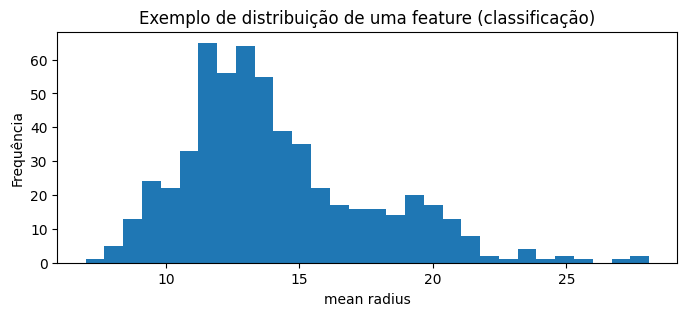

In [4]:
# Estatísticas descritivas e checagem de valores ausentes
print('--- Estatísticas (classificação) ---')
display(X_clf.describe().T)

print('\n--- Estatísticas (regressão) ---')
display(X_reg.describe().T)

print('\nValores ausentes (classificação):', X_clf.isna().sum().sum())
print('Valores ausentes (regressão):', X_reg.isna().sum().sum())

# Dica: sempre verifiquem distribuições das features antes de treinar modelos.
plt.figure(figsize=(8,3))
plt.hist(X_clf.iloc[:,0], bins=30)
plt.title('Exemplo de distribuição de uma feature (classificação)')
plt.xlabel(X_clf.columns[0])
plt.ylabel('Frequência')
plt.show()

## 3) Pré-processamento e limpeza (explicado passo a passo)
Nesta seção:
- Tratamos valores ausentes
- Separamos treino/teste
- Aplicamos escalonamento (StandardScaler)

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def preprocess(X, y, test_size=0.2, random_state=42, scaler='standard'):
    """
    Pré-processamento seguro para classificação e regressão.
    - Preenche NaNs (mediana)
    - Detecta automaticamente se y é categórico (usa stratify) ou contínuo (não usa stratify)
    - Aplica scaler ao X (fit no treino, transform no teste)
    Retorna: X_train, X_test, y_train, y_test, scaler_obj
    """
    X = X.copy()

    # 1) tratar valores ausentes (preenchimento simples por mediana)
    if hasattr(X, "isna") and X.isna().sum().sum() > 0:
        X = X.fillna(X.median())

    # converte y para numpy para inspeção
    y_arr = np.asarray(y)
    n_samples = y_arr.shape[0]
    n_unique = len(np.unique(y_arr))

    # heurística para detectar classificação:
    # - se y for inteiro (np.integer) e tiver número razoável de classes (<=50)
    # - ou se o número de classes for pequeno (<=20) (útil para rótulos codificados)
    is_integer = np.issubdtype(y_arr.dtype, np.integer)
    is_classification = (is_integer and n_unique <= 50) or (n_unique <= 20)

    # Se for classificação usamos stratify (mantém proporção de classes na amostra)
    strat = y if is_classification else None

    # 2) divisão treino/teste
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=strat
    )

    # 3) escalonamento
    if scaler == 'standard':
        scaler_obj = StandardScaler()
    elif scaler == 'minmax':
        scaler_obj = MinMaxScaler()
    else:
        scaler_obj = None

    if scaler_obj is not None:
        X_train = scaler_obj.fit_transform(X_train)
        X_test = scaler_obj.transform(X_test)
    else:
        X_train = X_train.values
        X_test = X_test.values

    return X_train, X_test, np.asarray(y_train), np.asarray(y_test), scaler_obj


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def preprocess(X, y, test_size=0.2, random_state=42, scaler='standard', is_classification=False):
    # 1) Cópia para evitar modificar o DataFrame original
    X = X.copy()

    # 2) Tratamento simples de valores ausentes: preencher pela mediana
    #    (método robusto para outliers; alternativa: mean ou regressão para imputação)
    if X.isna().sum().sum() > 0:
        X = X.fillna(X.median())

    # 3) Divisão treino/teste. Para classificação usamos stratify para manter proporção de classes.
    #    Para regressão, stratify deve ser None.
    strat = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=strat)

    # 4) Escalonamento — escolher entre StandardScaler (media=0,std=1) ou MinMaxScaler (0-1)
    if scaler == 'standard':
        scaler_obj = StandardScaler()
    elif scaler == 'minmax':
        scaler_obj = MinMaxScaler()
    else:
        scaler_obj = None

    if scaler_obj is not None:
        # Ajusta apenas no conjunto de treino e transforma treino e teste com os mesmos parâmetros
        X_train = scaler_obj.fit_transform(X_train)
        X_test = scaler_obj.transform(X_test)
    else:
        X_train = X_train.values
        X_test = X_test.values

    # Retorna arrays prontos para modelos (scikit-learn e Keras)
    return X_train, X_test, y_train.values, y_test.values, scaler_obj

# Aplicar preprocess nos dois conjuntos
Xc_train, Xc_test, yc_train, yc_test, scaler_clf = preprocess(X_clf, y_clf, scaler='standard', is_classification=True)
Xr_train, Xr_test, yr_train, yr_test, scaler_reg = preprocess(X_reg, y_reg, scaler='minmax', is_classification=False)

print('Classificação - shapes:', Xc_train.shape, Xc_test.shape)
print('Regressão   - shapes:', Xr_train.shape, Xr_test.shape)

Classificação - shapes: (455, 30) (114, 30)
Regressão   - shapes: (353, 10) (89, 10)


## 4) Treinar MLP para Classificação
Usaremos `MLPClassifier` do scikit-learn. A explicação inclui por que escolher arquitetura, função de ativação e solver.

In [7]:
# Instanciando o classificador MLP
mlp_clf = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', solver='adam', max_iter=500, random_state=42)

# Treinamento: o método .fit ajusta pesos via backpropagation
mlp_clf.fit(Xc_train, yc_train)

# Previsões no conjunto de teste
yc_pred = mlp_clf.predict(Xc_test)
yc_prob = mlp_clf.predict_proba(Xc_test)[:,1]

# Avaliação detalhada
acc = accuracy_score(yc_test, yc_pred)
cm = confusion_matrix(yc_test, yc_pred)
report = classification_report(yc_test, yc_pred, target_names=data_clf.target_names.astype(str))

print('Acurácia (teste):', round(acc,4))
print('\nMatriz de confusão:')
print(cm)
print('\nRelatório de classificação:')
print(report)

Acurácia (teste): 0.9649

Matriz de confusão:
[[41  1]
 [ 3 69]]

Relatório de classificação:
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



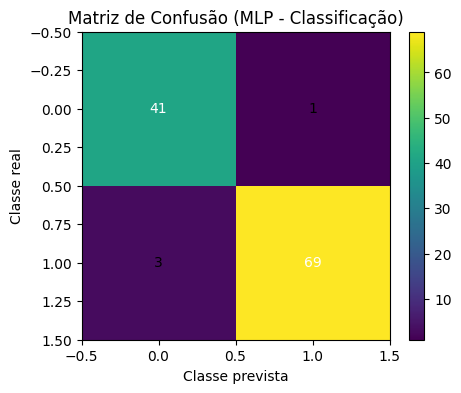

In [8]:
# Plot da matriz de confusão com anotações
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de Confusão (MLP - Classificação)')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.colorbar()
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, str(z), ha='center', va='center', color='white' if z>cm.max()/2 else 'black')
plt.show()

In [9]:
# ROC AUC - útil quando queremos medir performance em probabilidades
try:
    auc = roc_auc_score(yc_test, yc_prob)
    print('ROC AUC (teste):', round(auc,4))
except Exception as e:
    print('Não foi possível calcular ROC AUC:', e)

ROC AUC (teste): 0.9937


## 5) Treinar MLP para Regressão
Usamos `MLPRegressor` e avaliamos com MSE e R². Comentamos também sobre escala do target se necessário.

In [10]:
# MLPRegressor: arquitetura semelhante ao classificador, mas saída contínua
mlp_reg = MLPRegressor(hidden_layer_sizes=(64,32), activation='relu', solver='adam',learning_rate_init=0.001, max_iter=2000, random_state=42)

# Treina no conjunto de regressão
mlp_reg.fit(Xr_train, yr_train)

# Previsões
yr_pred = mlp_reg.predict(Xr_test)

# Métricas de regressão: MSE (erro quadrático médio) e R² (proporção de variância explicada)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print('RMSE (teste):', round(rmse,4))
print('R² (teste):', round(r2,4))

RMSE (teste): 53.5745
R² (teste): 0.4583


/home/victoriki/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


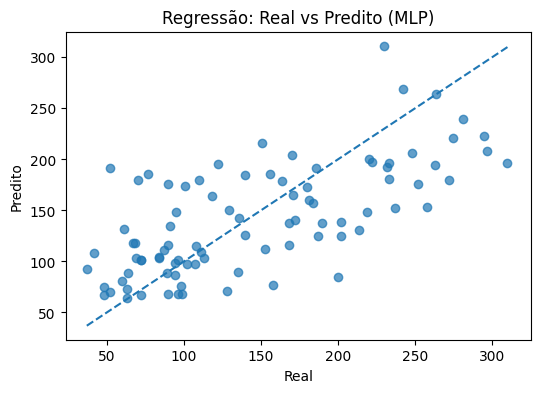

In [11]:
# Plot predito vs real (regressão) com linha identidade
plt.figure(figsize=(6,4))
plt.scatter(yr_test, yr_pred, alpha=0.7)
plt.title('Regressão: Real vs Predito (MLP)')
plt.xlabel('Real')
plt.ylabel('Predito')
mn = min(yr_test.min(), yr_pred.min())
mx = max(yr_test.max(), yr_pred.max())
plt.plot([mn,mx], [mn,mx], linestyle='--')
plt.show()


## 6) RNN (LSTM) — abordagem com janelas deslizantes
RNNs esperam sequências 3D: `(amostras, timesteps, features)`. Como nossas bases são tabulares, criaremos sequências usando janelas deslizantes apenas para demonstração didática.

**Importante:** Esta transformação é pedagógica. Para problemas reais de séries temporais, use dados que tenham ordem temporal natural.

In [12]:
# Função para criar sequências (janelas deslizantes)
def create_sequences(X, y, timesteps=3, stride=1):
    # X: array 2D (n_samples, n_features)
    Xs, ys = [], []
    for start in range(0, X.shape[0] - timesteps + 1, stride):
        end = start + timesteps
        Xs.append(X[start:end, :])
        ys.append(y[end-1])  # associamos a label/target ao último passo da janela
    return np.array(Xs), np.array(ys)

# Preparar sequências para regressão (exemplo)
timesteps = 5
Xr_all = np.vstack([Xr_train, Xr_test])  # concatenamos para criar janelas maiores (apenas didático)
yr_all = np.concatenate([yr_train, yr_test])

Xseq_reg, yseq_reg = create_sequences(Xr_all, yr_all, timesteps=timesteps)
print('Shape das sequências (regressão):', Xseq_reg.shape)

# Dividir sequências em treino/teste novamente
n_total = Xseq_reg.shape[0]
n_train = int(n_total * 0.7)
Xseq_r_train, Xseq_r_test = Xseq_reg[:n_train], Xseq_reg[n_train:]
yseq_r_train, yseq_r_test = yseq_reg[:n_train], yseq_reg[n_train:]

print('Treino seq:', Xseq_r_train.shape, 'Teste seq:', Xseq_r_test.shape)

Shape das sequências (regressão): (438, 5, 10)
Treino seq: (306, 5, 10) Teste seq: (132, 5, 10)


In [13]:
# Construir e treinar LSTM para regressão
tf.random.set_seed(42)

model_lstm_reg = Sequential([
    LSTM(64, input_shape=(Xseq_r_train.shape[1], Xseq_r_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)  # saída contínua
])

# Compilar modelo: otimizador e função de perda (MSE para regressão)
model_lstm_reg.compile(optimizer='adam', loss='mse', metrics=['mse'])
model_lstm_reg.summary()

# EarlyStopping para evitar overfitting — restaura melhores pesos observados na validação
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_lstm_reg.fit(Xseq_r_train, yseq_r_train, validation_data=(Xseq_r_test, yseq_r_test),
                            epochs=100, batch_size=16, callbacks=[es], verbose=1)

# Avaliação no conjunto de teste das sequências
y_lstm_pred = model_lstm_reg.predict(Xseq_r_test).ravel()
print('MSE LSTM (teste):', round(mean_squared_error(yseq_r_test, y_lstm_pred),4))
print('R2 LSTM (teste):', round(r2_score(yseq_r_test, y_lstm_pred),4))

2025-12-05 07:53:49.490052: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/victoriki/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,313 (83.25 KB)

 Trainable params: 21,313 (83.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 30010.7578 - mse: 30010.7578 - val_loss: 25897.3145 - val_mse: 25897.3145
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 29116.4746 - mse: 29116.4746 - val_loss: 24281.9336 - val_mse: 24281.9336
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 26855.1094 - mse: 26855.1094 - val_loss: 21992.5410 - val_mse: 21992.5410
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 24656.8027 - mse: 24656.8027 - val_loss: 20152.2500 - val_mse: 20152.2500
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 22726.0449 - mse: 22726.0449 - val_loss: 18388.5938 - val_mse: 18388.5938
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 20824.3223 - mse: 20824.3223 - val_loss: 16644.4727 - val_mse: 16644.4727
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 18939.4258 - mse: 18939.4258 - val_loss: 14937.8379 - val_mse: 14937.8379
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 17

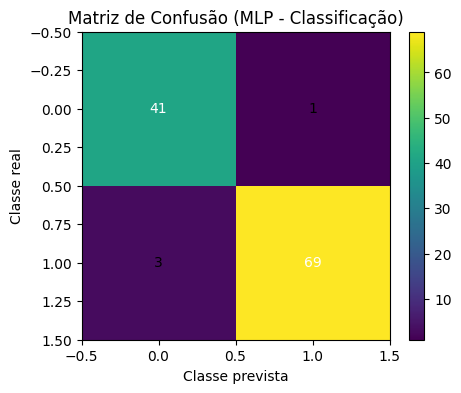

In [14]:
# Plot da matriz de confusão com anotações
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Matriz de Confusão (MLP - Classificação)')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.colorbar()
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, str(z), ha='center', va='center', color='white' if z>cm.max()/2 else 'black')
plt.show()

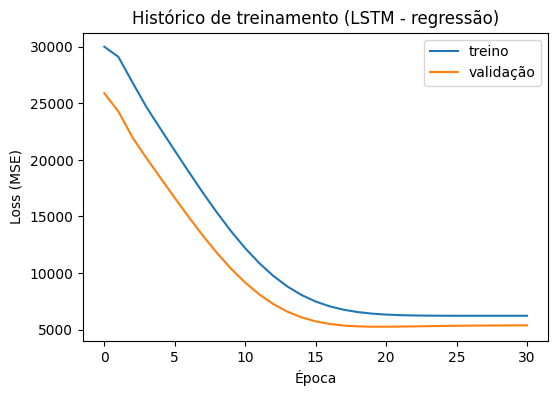

In [15]:
# Plot da loss de treino e validação (LSTM - regressão)
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('Histórico de treinamento (LSTM - regressão)')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [16]:
# Preparar sequências para classificação (dados de classificação)
Xc_all = np.vstack([Xc_train, Xc_test])
yc_all = np.concatenate([yc_train, yc_test])

timesteps_clf = 4
Xseq_clf, yseq_clf = create_sequences(Xc_all, yc_all, timesteps=timesteps_clf)
print('Sequências (classificação) shape:', Xseq_clf.shape)

n_total = Xseq_clf.shape[0]
n_train = int(n_total * 0.75)
Xseq_c_train, Xseq_c_test = Xseq_clf[:n_train], Xseq_clf[n_train:]
yseq_c_train, yseq_c_test = yseq_clf[:n_train], yseq_clf[n_train:]

# Modelo LSTM para classificação binária
tf.random.set_seed(42)
model_lstm_clf = Sequential([
    LSTM(64, input_shape=(Xseq_c_train.shape[1], Xseq_c_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # saída entre 0 e 1 -> probabilidade
])

model_lstm_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_clf = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_clf = model_lstm_clf.fit(Xseq_c_train, yseq_c_train, validation_data=(Xseq_c_test, yseq_c_test),
                                epochs=80, batch_size=32, callbacks=[es_clf], verbose=1)

# Avaliação
y_lstm_c_prob = model_lstm_clf.predict(Xseq_c_test).ravel()
y_lstm_c_pred = (y_lstm_c_prob > 0.5).astype(int)
print('Acurácia LSTM (teste):', round(accuracy_score(yseq_c_test, y_lstm_c_pred),4))
print('\nMatriz de confusão:')
print(confusion_matrix(yseq_c_test, y_lstm_c_pred))

Sequências (classificação) shape: (566, 4, 30)


/home/victoriki/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6557 - loss: 0.6485 - val_accuracy: 0.8169 - val_loss: 0.5775
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8255 - loss: 0.5037 - val_accuracy: 0.8662 - val_loss: 0.4479
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8844 - loss: 0.3683 - val_accuracy: 0.9225 - val_loss: 0.3051
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9458 - loss: 0.2252 - val_accuracy: 0.9366 - val_loss: 0.1987
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9693 - loss: 0.1284 - val_accuracy: 0.9507 - val_loss: 0.1580
Epoch 6/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9764 - loss: 0.0899 - val_accuracy: 0.9507 - val_loss: 0.1374
Epoch 7/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9835 - loss: 0.0723 - val_accuracy: 0.9437 - val_loss: 0.1254
Epoch 8/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9858 - loss: 0.0614 - val_accuracy: 0.9366 - v

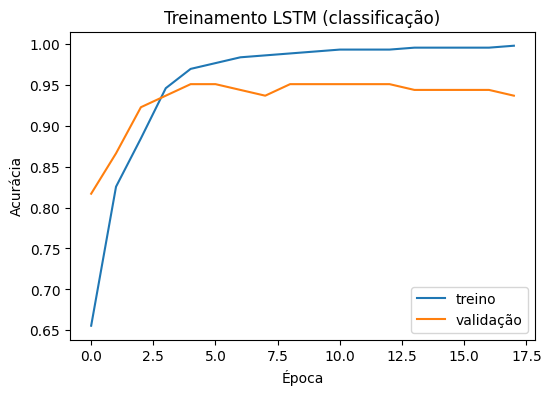

In [17]:
# Plot do histórico de accuracy (treino vs validação)
plt.figure(figsize=(6,4))
plt.plot(history_clf.history['accuracy'], label='treino')
plt.plot(history_clf.history['val_accuracy'], label='validação')
plt.title('Treinamento LSTM (classificação)')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

## 7) Conclusões

- **MLP (scikit-learn):** fácil de usar para dados tabulares. Importante fazer escalonamento e tentar várias arquiteturas. Use `alpha` para regularização L2 se houver overfitting.
- **RNN/LSTM (Keras):** projetado para sequências; a conversão por janelas é didática (para facilitar o entendimento). Para problemas reais, utilize séries temporais autênticas.

## 8) Tarefas
1. **Arquiteturas:** variar número de camadas ocultas e neurônios (ex.: (32,), (128,64,32)) e documentar impacto nas métricas.
2. **Regularização e otimização:** testar `alpha` no MLP, adicionar `Dropout` entre camadas LSTM/Dense, tentar otimizadores diferentes (SGD com momentum, RMSprop).
3. **Normalização do target (regressão):** normalizar `y` durante treino e reverter a transformação para relatar métricas reais.
4. **Validação cruzada:** implementar cross-validation para MLP usando `cross_val_score` e comparar com divisão simples treino/teste.
5. **Feature importance / seleção:** usar `PermutationImportance` ou RFE para reduzir features e checar desempenho.
6. **Salvar/carregar modelos:** usar `joblib.dump`/`load` para modelos scikit-learn e `model.save()` / `load_model()` para Keras.
7. **Substituir dados sintéticos por reais:** buscar uma série temporal real (ex.: séries financeiras ou séries clínicas) e comparar LSTM vs modelos tradicionais (ARIMA, RandomForest, MLP).